# Understanding Social Inequality and Housing Trends in Singapore’s HDB Landscape Using Data Analytics
**Author:** Jenyasri Senthil Kumar

## Research Question: 
How do HDB resale prices vary across towns, and what does this reveal about inequality and accessibility in Singapore?

### Objective:
- Analyse trends in HDB resale prices across towns.
- Identify key socio-economic factors driving prices.
- Build a predictive model to forecast resale prices.
- Derive insights relevant to business (investment potential) and society (affordability and inequality).

## Introduction

### Why housing matters in Singapore?
- Housing is a basic necessity that affects quality of life, financial stability and social mobility.
- In Singapore, housing is closely tied to economic security, as property ownership is a major form of wealth accumulation.
- The housing market influences cost of living which impacts individuals’ ability to save, invest and plan for the future.
- Accessibility to housing also affects social equality, as disparities in affordability can widen income and opportunity gaps.

### Why HDB is important?
- The Housing & Development Board provides housing to over 80% of Singapore’s population, making it central to national housing policy.
- HDB ensures widespread home ownership, which promotes social stability and community cohesion.
- It plays a key role in urban planning, shaping the development of towns and access to amenities.
- Despite its aim of affordability, rising resale prices have raised concerns about whether public housing remains accessible to all groups.

### Why is my research question relevant?
- Rising housing prices in Singapore have made affordability a growing concern, especially for younger and first-time buyers.
- Since a large majority of Singapore’s population lives in public housing, trends in resale prices have a direct impact on the everyday lives of citizens.
- Differences in housing prices across towns highlight potential spatial inequality, where access to better locations may be limited by income.
- Analysing factors such as flat size and remaining lease helps identify the key drivers of housing prices, which is important for understanding how the market functions.
- Housing is a major financial commitment, so changes in prices can affect wealth distribution and long-term financial security.
- Understanding these trends provides insights into broader social and economic patterns, such as inequality and accessibility.
- The findings can help inform discussions on housing policies, including how to maintain affordability and ensure equitable access to housing.
- Therefore, this research question is relevant as it uses data-driven analysis to examine real-world issues of affordability, inequality, and social impact within Singapore’s housing system.

## Import Libraries

In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load Data

In [3]:
df = pd.read_csv(r'C:\Users\65866\Desktop\Jenya University\Data Analysis Project\hdb_resale.csv')
df.head()

,month,town,flat_type,floor_area_sqm,remaining_lease,resale_price
0,2017-01,ANG MO KIO,2 ROOM,44.0,61 years 04 months,232000.0
1,2017-01,ANG MO KIO,3 ROOM,67.0,60 years 07 months,250000.0
2,2017-01,ANG MO KIO,3 ROOM,67.0,62 years 05 months,262000.0
3,2017-01,ANG MO KIO,3 ROOM,68.0,62 years 01 month,265000.0
4,2017-01,ANG MO KIO,3 ROOM,67.0,62 years 05 months,265000.0


## Data Cleaning

In [4]:
df['month'] = pd.to_datetime(df['month'])

In [5]:
df['year'] = df['month'].dt.year

In [6]:
df.isnull().sum()

month              0
town               0
flat_type          0
floor_area_sqm     0
remaining_lease    0
resale_price       0
year               0
dtype: int64

In [7]:
df['remaining_lease'] = df['remaining_lease'].str.extract('(\d+)').astype(float)

In [8]:
df.dtypes

month              datetime64[ns]
town                       object
flat_type                  object
floor_area_sqm            float64
remaining_lease           float64
resale_price              float64
year                        int32
dtype: object

## Explatory Data Analysis

## 1. Price Trend Over Time

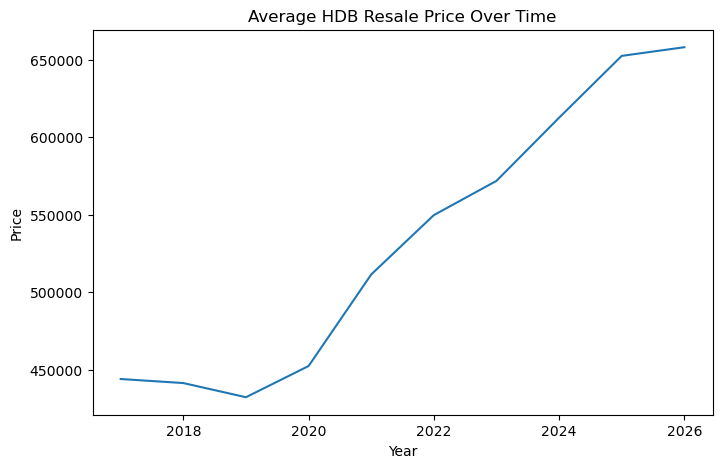

In [34]:
price_trend = df.groupby('year')['resale_price'].mean()

plt.figure(figsize=(8,5))
price_trend.plot()

plt.title("Average HDB Resale Price Over Time")
plt.xlabel("Year")
plt.ylabel("Price")

plt.show()

### Insight:
- Clear upward trend in HDB resale prices over the years.
- Prices increase more rapidly in recent years, indicating accelerating demand.
- Few or no significant declines suggests strong market resilience.

### Interpretation:
- Housing in Singapore is becoming progressively more expensive and less affordable.
- Demand for resale flats is likely outpacing supply.

### Social Impact:
- New and younger buyers may face greater financial barriers to home ownership.
- Rising prices may widen the gap between homeowners and non-homeowners.

## 2. Prices by Town

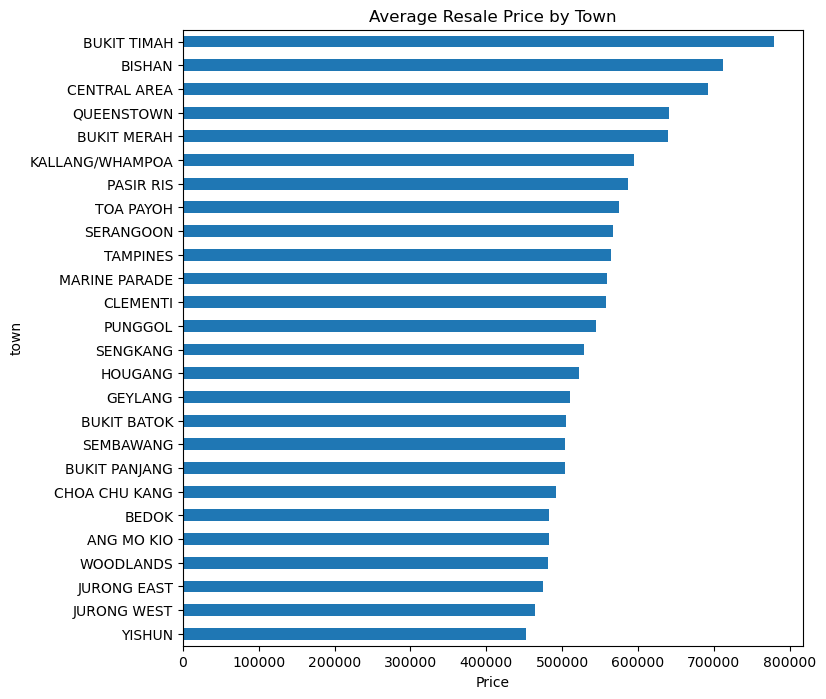

In [24]:
town_prices = df.groupby('town')['resale_price'].mean().sort_values()

plt.figure(figsize=(8,8))
town_prices.plot(kind='barh')

plt.title("Average Resale Price by Town")
plt.xlabel("Price")

plt.show()

### Insight:
- Certain towns consistently show higher average prices.
- Central or mature estates tend to be more expensive than peripheral towns.
- Some towns remain significantly more affordable, showing clear disparities.
  
### Interpretation:
- Housing prices are not evenly distributed geographically.
- Location plays a major role in determining housing value.

### Social Impact:
- Creates spatial inequality—wealthier individuals can access better-located housing.
- Lower-income groups may be pushed to less connected or less developed areas.

## 3. Price per sqm

In [19]:
df['price_per_sqm'] = df['resale_price'] / df['floor_area_sqm']

## 4. Price per sqm per town

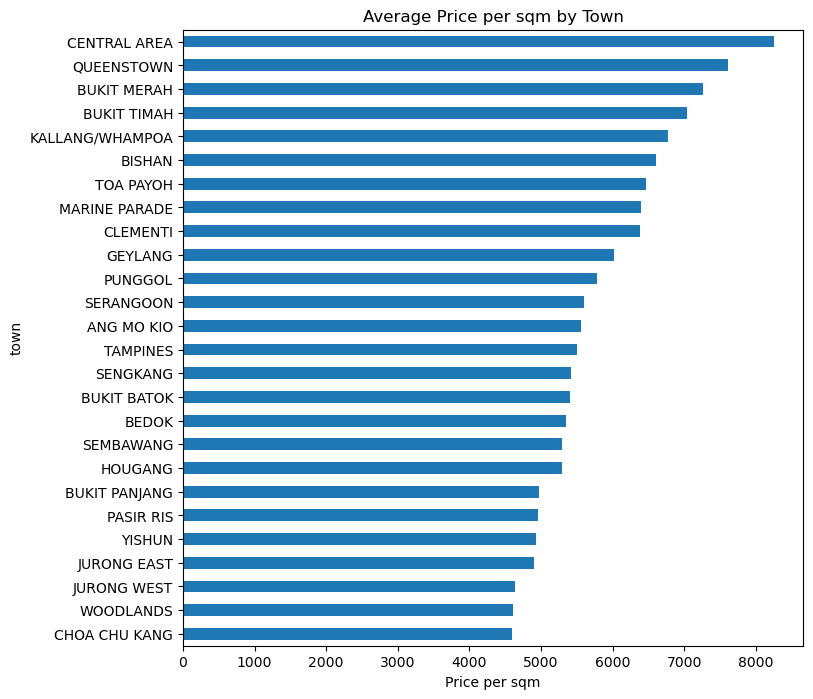

In [25]:
price_sqm = df.groupby('town')['price_per_sqm'].mean().sort_values()

plt.figure(figsize=(8,8))
price_sqm.plot(kind='barh')

plt.title("Average Price per sqm by Town")
plt.xlabel("Price per sqm")

plt.show()

### Insight:
- Some towns have higher price per sqm despite smaller flats.
- Differences in price per sqm reveal true value of location, not just size.
- High-demand areas command a higher premium per unit space.

### Interpretation:
- Expensive towns are not just larger, they are more valuable per unit area.
- Indicates strong demand for specific locations.

### Social Impact:
- Suggests that land scarcity and desirability drive inequality.
- Even smaller homes in prime areas may be unaffordable to average buyers.

## 5. Flat type vs. Price

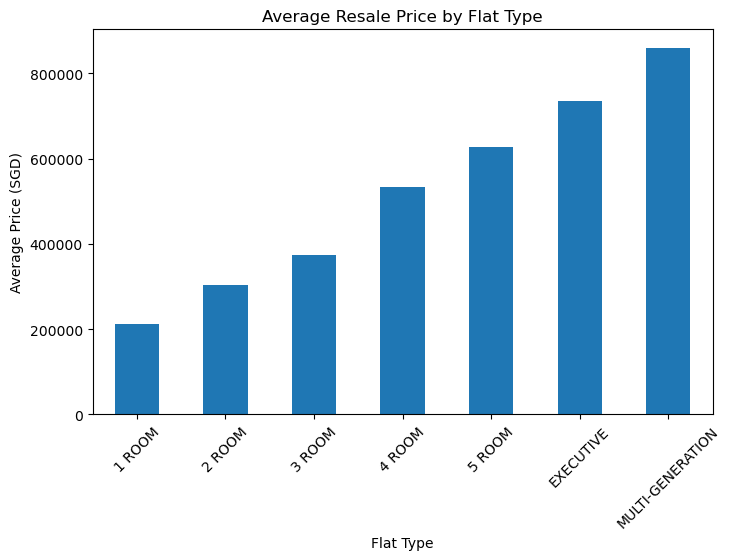

In [20]:
avg_price = df.groupby('flat_type')['resale_price'].mean().sort_values()

plt.figure(figsize=(8,5))
avg_price.plot(kind='bar')

plt.title("Average Resale Price by Flat Type")
plt.xlabel("Flat Type")
plt.ylabel("Average Price (SGD)")
plt.xticks(rotation=45)

plt.show()

### Insight:
- Larger flats have higher resale prices.
- Price increases with flat size, but not always proportionally.
- Smaller flats remain more affordable but still show rising price trends.

### Interpretation:
- Flat size is a key determinant of price.
- Buyers pay a higher premium for space and comfort.

### Social Impact:
- Lower-income households may be limited to smaller living spaces, even if they require more.
- Highlights inequality in living standards, not just ownership.

## 6. Lease vs. Price

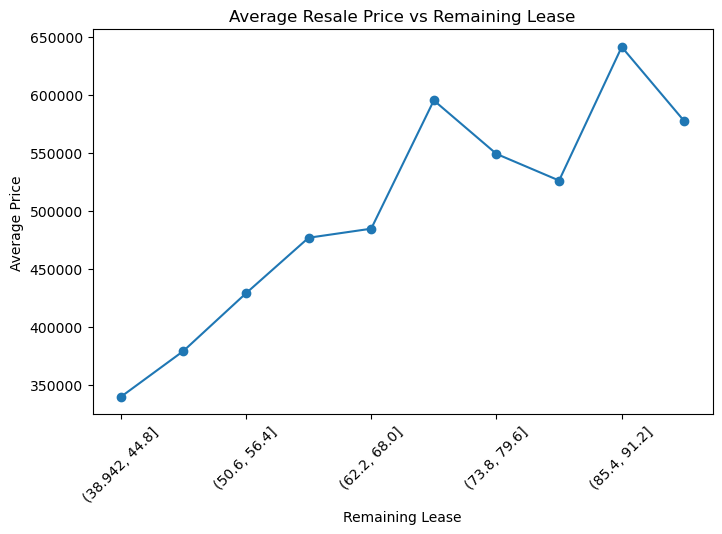

In [30]:
# Create lease bins
df['lease_bin'] = pd.cut(df['remaining_lease'], bins=10)

# Calculate average price per bin
lease_price = df.groupby('lease_bin', observed=False)['resale_price'].mean()

# Plot
plt.figure(figsize=(8,5))
lease_price.plot(marker='o')

plt.title("Average Resale Price vs Remaining Lease")
plt.xlabel("Remaining Lease")
plt.ylabel("Average Price")
plt.xticks(rotation=45)

plt.show()

### Insight:
- Flats with longer remaining leases have higher prices.
- Prices decline as lease duration decreases.
- Relationship exists but may not be perfectly strong as other factors also matter.

### Interpretation:
- Buyers value long-term security of ownership.
- Lease decay reduces perceived value of flats.

### Social Impact:
- Older flats may become less attractive and harder to sell.
- Could lead to wealth erosion for owners of ageing properties.

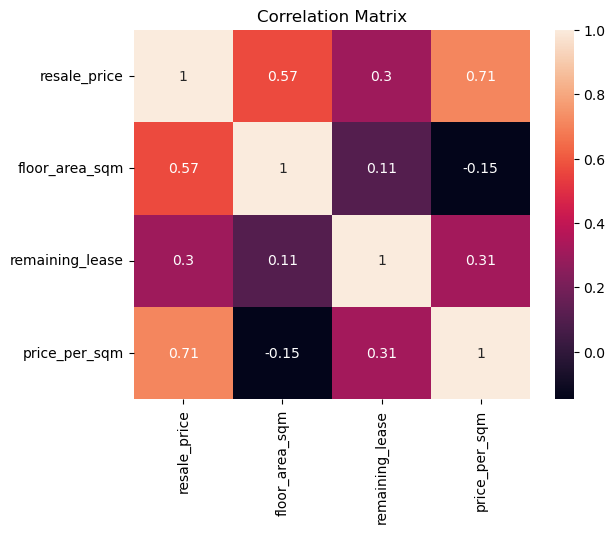

In [31]:
import seaborn as sns

corr = df[['resale_price', 'floor_area_sqm', 'remaining_lease', 'price_per_sqm']].corr()

sns.heatmap(corr, annot=True)
plt.title("Correlation Matrix")
plt.show()

### Interpretation for correlation table:

| Value      | Meaning                                                                          |
| ---------- | -------------------------------------------------------------------------------- |
| 1          | Perfect positive correlation (when one increases, the other increases perfectly) |
| 0.7–0.99   | Strong positive correlation                                                      |
| 0.3–0.69   | Moderate positive correlation                                                    |
| 0–0.29     | Weak positive correlation                                                        |
| 0          | No correlation                                                                   |
| -0.29–0    | Weak negative correlation                                                        |
| -0.3–-0.69 | Moderate negative correlation                                                    |
| -0.7–-0.99 | Strong negative correlation                                                      |
| -1         | Perfect negative correlation (when one increases, the other decreases perfectly) |


### Insight:
- Strong correlation between resale price and price per sqm.
- Moderate positive correlation between floor area sqm and resale price.
- Moderate correlation between remaining lease and resale price.

### Interpretation:
- Size is a major driver of price.
- Lease length plays a smaller role than expected.
- Multiple factors influence pricing simultaneously.

### Social Impact:
- Larger homes are consistently more expensive, reinforcing wealth-based inequality.
- Market prioritises space and location over long-term lease concerns.

### Top 5 most expensive towns

In [32]:
town_prices.sort_values(ascending=False).head()

town
BUKIT TIMAH     778878.280360
BISHAN          711723.939356
CENTRAL AREA    691998.208620
QUEENSTOWN      640891.235407
BUKIT MERAH     639317.710927
Name: resale_price, dtype: float64

### Top 5 cheapest towns

In [33]:
town_prices.head()

town
YISHUN         452367.439169
JURONG WEST    464025.608332
JURONG EAST    474519.745690
WOODLANDS      481176.479822
ANG MO KIO     482142.991877
Name: resale_price, dtype: float64

### Concluding insights:

- Singapore’s HDB market shows rising prices and increasing demand.
- There is clear geographical inequality in housing affordability.
- Price per sqm highlights hidden disparities in land value and desirability.
- Housing inequality is not just about ownership, but also quality and location of housing.

## Conclusion

Overall, the analysis reveals that Singapore’s public housing market, while widely accessible, still exhibits significant inequalities in affordability, location, and living standards which raises important considerations for future housing policy.